# Mathematics for Data Science (COM7023) Assessment
Performing investigations: using advanced mathematical techniques on a real-world data analytics problem for Urban Resource Intelligence.

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp

plt.style.use('default')

## Question 1: Linear Algebra
The system of equations can be expressed in the form `Ax=b` (where A is the coefficient matrix, x for the variables, and b for the independent terms) and will be solved as follows:

In [29]:
# 1. calculation
A = np.array([
    [2, -1, 1, 0],
    [-1, 3, 0, -1],
    [1, 1, 2, -1],
    [0, -1, 1, 2]
], dtype=float)

b = np.array([120, 150, 180, 140], dtype=float)

x = np.linalg.solve(A, b)
result = [round(i, 2) for i in x]
print(f"""Result:
  x1 = {result[0]}
  x2 = {result[1]}
  x3 = {result[2]}
  x4 = {result[3]}""")

# 2. uniqueness check
det = np.linalg.det(A)
print(f'Det(A) = {det}')

Result:
  x1 = 105.0
  x2 = 123.33
  x3 = 33.33
  x4 = 115.0
Det(A) = 12.0


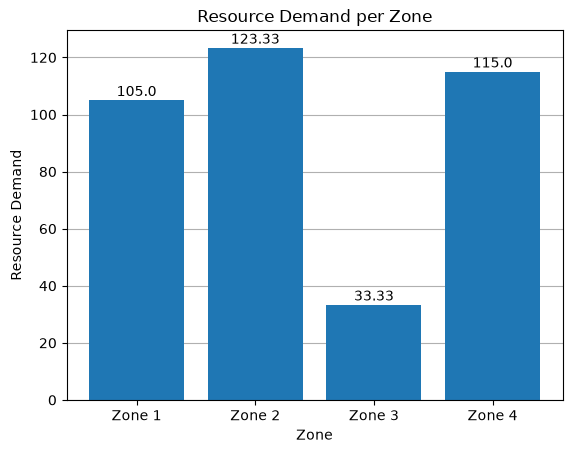

In [30]:
# 3. visualization
x = np.array(["Zone 1", "Zone 2", "Zone 3", "Zone 4"])
y = result
plt.bar(x, y,)
for i in range(len(x)):
    plt.text(x[i], y[i] + 1.5, str(y[i]), ha='center')
plt.xlabel("Zone")
plt.ylabel("Resource Demand")
plt.title("Resource Demand per Zone")
plt.grid(axis='y')
plt.gca().set_axisbelow(True)
plt.show()

## Question 2: Calculus
Analysis of demand over time within a high-density residential area. The rate of demand is modeled as a cubic function such that it should be analyzed:
- to examine rates of change
- to identify periods of rapid increase or decrease
- to determine any critical points
- to determine how the analysis supports peak-demand management

In [36]:
t = sp.symbols('t')
d = 4*t**3 - 18*t**2 + 24*t + 90
print('Demand function:')
sp.pprint(d)

d1 = sp.diff(d, t)
print('\nFirst derivative:')
sp.pprint(d1)

print('\nFactorized first derivative:')
sp.pprint(sp.factor(d1))

critical_points = sp.solve(d1, t)
print('\nCritical points:', critical_points)

d2 = sp.diff(d1, t)
print('\nSecond derivative:')
sp.pprint(d2)

print('\nSecond derivative test:')
for point in critical_points:
    print(f"D''({point}) =", d2.subs(t, point))

print("\nDemand at Critical Points:")
for point in critical_points:
    print(f"D({point}) =", d.subs(t, point))

print("\nBaseline Demand:\n")
print("D(0) =", d.subs(t, 0))

for item in [d, d1, d2]:
    print(item)

Demand function:
   3       2            
4⋅t  - 18⋅t  + 24⋅t + 90

First derivative:
    2            
12⋅t  - 36⋅t + 24

Factorized first derivative:
12⋅(t - 2)⋅(t - 1)

Critical points: [1, 2]

Second derivative:
24⋅t - 36

Second derivative test:
D''(1) = -12
D''(2) = 12

Demand at Critical Points:
D(1) = 100
D(2) = 98

Baseline Demand:

D(0) = 90
4*t**3 - 18*t**2 + 24*t + 90
12*t**2 - 36*t + 24
24*t - 36


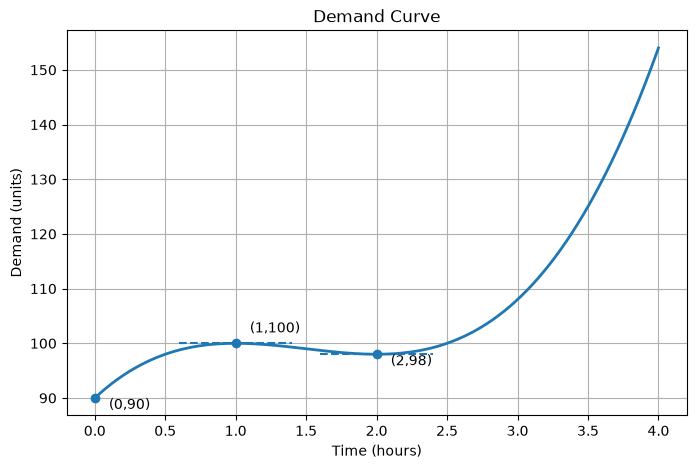

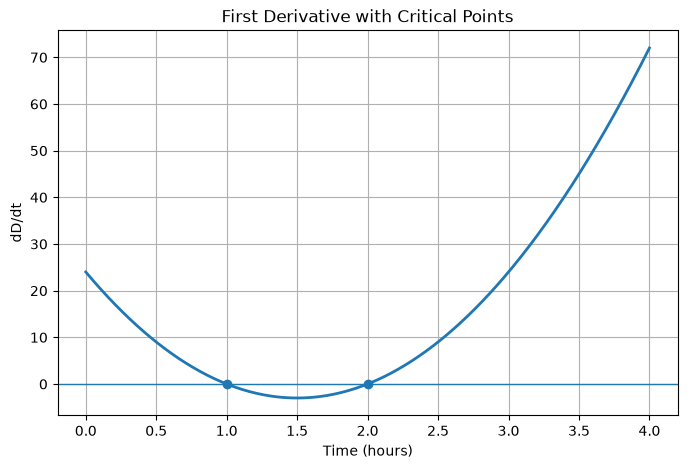

In [52]:
# Time values
t = np.linspace(0, 4, 400)

# Functions
D = 4*t**3 - 18*t**2 + 24*t + 90
D1 = 12*t**2 - 36*t + 24
D2 = 24*t - 36

# Critical points
critical_t = np.array([0, 1, 2])
critical_D = 4*critical_t**3 - 18*critical_t**2 + 24*critical_t + 90

# demand function
plt.figure(figsize=(8,5))
plt.plot(t, D, linewidth=2)
plt.scatter(critical_t, critical_D, zorder=3)
plt.hlines(100, 0.6, 1.4, linestyles='dashed')
plt.hlines(98, 1.6, 2.4, linestyles='dashed')
plt.annotate("(1,100)", (1,100), xytext=(1.1,102))
plt.annotate("(2,98)", (2,98), xytext=(2.1,96))
plt.annotate("(0,90)", (0,90), xytext=(0.1,88))
plt.xlabel("Time (hours)")
plt.ylabel("Demand (units)")
plt.title("Demand Curve")
plt.grid(True)
plt.show()

# first derivative with critical points
plt.figure(figsize=(8,5))
plt.plot(t, D1, linewidth=2)
plt.axhline(0, linewidth=1)
plt.scatter([1,2],[0,0], zorder=3)
plt.xlabel("Time (hours)")
plt.ylabel("dD/dt")
plt.title("First Derivative with Critical Points")
plt.grid(True)
plt.show()